# Modelo de ML clásico — R-01 Clasificación de solicitudes entrantes

Línea base con TF-IDF + Regresión Logística sobre el histórico de tickets
limpio (salida de Etapa 1, reutilizando `src.limpiar_tickets` en vez de
reimplementar la limpieza). Este notebook no se integra al pipeline
TypeScript — el Anexo A permite entregar el modelo de ML clásico como
notebook exploratorio para la versión de 3 días (ver
`docs/superpowers/specs/2026-08-22-etapa5-estrategia-evaluacion-design.md`,
sección 1). Comparación de costo/latencia/precisión contra el enfoque LLM
en `docs/comparacion-enfoques.md`.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path("../etapa1-fundamentos").resolve()))
import csv
from src.limpiar_tickets import limpiar

with open("../materiales/datos/tickets_historicos.csv", encoding="utf-8") as fh:
    tickets_crudos = list(csv.DictReader(fh))

validos, descartados, duplicados = limpiar(tickets_crudos)
print(f"Validos: {len(validos)}  Descartados: {len(descartados)}  Duplicados eliminados: {duplicados}")

Validos: 1909  Descartados: 51  Duplicados eliminados: 40


In [2]:
import pandas as pd

df = pd.DataFrame(validos)
df["texto"] = df["asunto"].fillna("") + " " + df["descripcion"].fillna("")
conteo = df["categoria"].value_counts()
print(conteo)

categoria
Software              159
Accesos               149
Hardware              145
Nomina                131
Aplicaciones          126
Vacaciones            109
Incidente             105
Otros                 101
Viaticos              100
Red                   100
Gestion de accesos     96
Capacitacion           78
Equipos                77
Informes               64
Ordenes de compra      61
Conectividad           59
Compras                58
Reportes               54
Acceso                 39
Incidentes             32
Sin clasificar         31
Name: count, dtype: int64


In [3]:
# Se excluyen categorias con menos de 5 casos: son demasiado pocas para
# entrenar/evaluar de forma confiable, y en produccion ese volumen bajo
# justificaria una regla manual antes que un modelo entrenado.
categorias_validas = conteo[conteo >= 5].index
df_filtrado = df[df["categoria"].isin(categorias_validas)].copy()
print(f"Categorias usadas: {len(categorias_validas)} de {len(conteo)} (excluidas por <5 casos: {len(conteo) - len(categorias_validas)})")
print(f"Filas para entrenar/evaluar: {len(df_filtrado)} de {len(df)}")

Categorias usadas: 21 de 21 (excluidas por <5 casos: 0)
Filas para entrenar/evaluar: 1874 de 1909


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df_filtrado["texto"], df_filtrado["categoria"],
    test_size=0.2, random_state=42, stratify=df_filtrado["categoria"],
)
print(f"Entrenamiento: {len(X_train)}  Prueba: {len(X_test)}")

Entrenamiento: 1499  Prueba: 375


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

modelo = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=2000, ngram_range=(1, 2))),
    ("clf", LogisticRegression(max_iter=1000)),
])
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)
print("Entrenamiento completo.")

Entrenamiento completo.


In [6]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, zero_division=0))

                    precision    recall  f1-score   support

            Acceso       0.00      0.00      0.00         8
           Accesos       0.51      0.93      0.66        30
      Aplicaciones       0.41      0.36      0.38        25
      Capacitacion       1.00      1.00      1.00        16
           Compras       0.50      0.42      0.45        12
      Conectividad       0.00      0.00      0.00        12
           Equipos       0.00      0.00      0.00        15
Gestion de accesos       0.00      0.00      0.00        19
          Hardware       0.65      0.97      0.78        29
         Incidente       0.78      1.00      0.88        21
        Incidentes       0.00      0.00      0.00         6
          Informes       0.47      0.69      0.56        13
            Nomina       1.00      1.00      1.00        26
 Ordenes de compra       0.50      0.58      0.54        12
             Otros       0.77      1.00      0.87        20
               Red       0.62      1.00

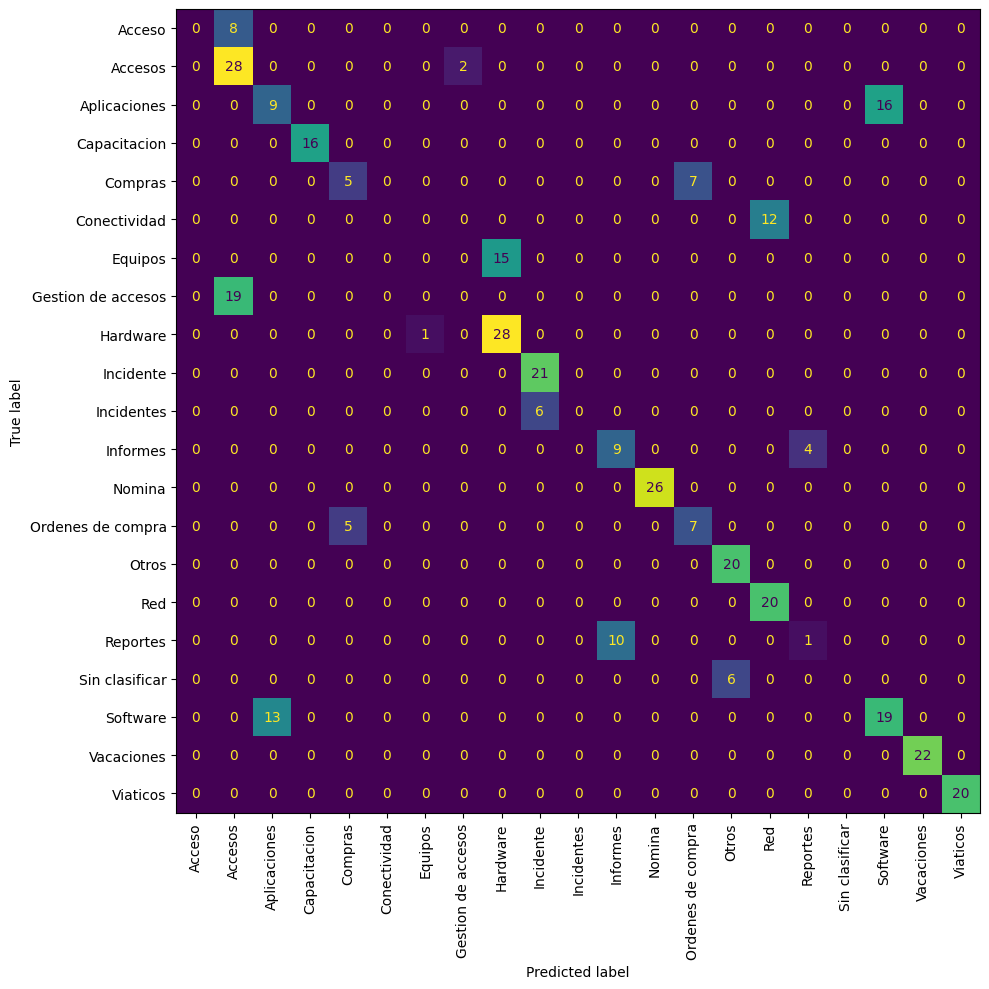

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

etiquetas = sorted(df_filtrado["categoria"].unique())
matriz = confusion_matrix(y_test, y_pred, labels=etiquetas)
fig, ax = plt.subplots(figsize=(10, 10))
ConfusionMatrixDisplay(matriz, display_labels=etiquetas).plot(ax=ax, xticks_rotation=90, colorbar=False)
plt.tight_layout()
plt.savefig("matriz_confusion.png")
plt.show()

In [8]:
pares = []
for i, cat_real in enumerate(etiquetas):
    for j, cat_predicha in enumerate(etiquetas):
        if i != j and matriz[i, j] > 0:
            pares.append((matriz[i, j], cat_real, cat_predicha))
pares.sort(reverse=True)

print("Top confusiones (categoria real -> categoria predicha : cantidad):")
for cantidad, real, predicha in pares[:8]:
    print(f"  {real} -> {predicha} : {cantidad}")

Top confusiones (categoria real -> categoria predicha : cantidad):
  Gestion de accesos -> Accesos : 19
  Aplicaciones -> Software : 16
  Equipos -> Hardware : 15
  Software -> Aplicaciones : 13
  Conectividad -> Red : 12
  Reportes -> Informes : 10
  Acceso -> Accesos : 8
  Compras -> Ordenes de compra : 7


## Lectura en términos de negocio

- **Confusiones principales**: los tres pares más frecuentes en esta
  ejecución son `Gestion de accesos -> Accesos` (19 casos),
  `Aplicaciones -> Software` (16 casos) y `Equipos -> Hardware` (15 casos),
  seguidos de cerca por `Software -> Aplicaciones` (13),
  `Conectividad -> Red` (12) y `Reportes -> Informes` (10). El patrón es
  consistente: no son errores semánticos aleatorios, sino pares de
  categorías que son variantes/sinónimos del mismo concepto en el histórico
  crudo. De hecho, tras la limpieza de Etapa 1 el histórico contiene **21**
  valores de categoría distintos (`conteo` más arriba), no los 12 del
  catálogo oficial descrito en `materiales/n5/requerimientos_negocio.md` —
  la limpieza de Etapa 1 normaliza acentos/mayúsculas pero no fusiona
  singular/plural ni sinónimos (`Acceso`/`Accesos`, `Incidente`/
  `Incidentes`, `Equipos`/`Hardware`, `Aplicaciones`/`Software`,
  `Conectividad`/`Red`), así que buena parte de la matriz de confusión es en
  realidad el modelo detectando correctamente que dos etiquetas son casi el
  mismo texto.
- **Implicación operativa para R-01**: la accuracy global observada es 0.67,
  es decir, en el conjunto de prueba 1 de cada 3 tickets queda mal
  clasificado. A la corrección de <1 minuto y sin efecto en el usuario
  final (ver `materiales/n5/requerimientos_negocio.md`) eso no es gratis a
  escala: sobre 3.000 solicitudes/día, un 33% de error implicaría del orden
  de ~990 correcciones diarias, es decir, del orden de 15-16 horas-persona/
  día si cada corrección tomara cerca de un minuto — lejos de ser un costo
  despreciable, aunque siga siendo manejable por lote (el proceso corre
  cada hora, sin exigencia de tiempo real). Sin embargo, dado que buena
  parte del error (los pares listados arriba) proviene de categorías
  duplicadas/sinónimas en el catálogo crudo y no de una confusión genuina
  entre conceptos distintos, la magnitud real del problema es más chica de
  lo que sugiere la accuracy bruta: consolidar esas categorías en el
  catálogo (antes de reentrenar) debería reducir el volumen de correcciones
  de forma significativa sin cambiar de enfoque de modelo.
- **¿Sostiene la recomendación de `docs/decision-requerimientos.md` (R-01:
  automatización tradicional/ML clásico, no LLM)?** Sí, mantiene la
  recomendación en costo/latencia/tolerancia al error — el proceso batch
  sin restricción de tiempo real y el bajo costo de corrección (<1 minuto,
  sin impacto en el usuario final) siguen favoreciendo un modelo clásico
  sobre un LLM. Pero la accuracy real (0.67) sí desafía la lectura optimista
  implícita de esa decisión: no alcanza para operar sin monitoreo, como ya
  anticipaba el documento de decisión al señalar el riesgo de "degradación
  silenciosa". La causa raíz observada aquí (categorías del catálogo
  histórico no consolidadas: 21 valores vs. 12 oficiales) no es un problema
  que un LLM resolvería mejor de forma automática — un LLM sin el catálogo
  canónico como contexto enfrentaría la misma ambigüedad entre `Equipos`/
  `Hardware` o `Acceso`/`Accesos`. La acción recomendada es consolidar el
  catálogo de categorías antes de decidir si vale la pena invertir en un
  modelo más sofisticado, no cambiar de ML clásico a LLM.